In [2]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

c:\Users\Zaheer jk\AppData\Local\anaconda3\envs\ai-ml\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
DATASET_DIR="../DATA"
IMG_HEIGHT=224
IMG_WIDTH=224
BATCH_SIZE=32
SEED=42

In [7]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed =SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [8]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    subset='validation',
    batch_size=BATCH_SIZE,
    seed =SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [9]:
class_names=train_dataset.class_names
num_classes=len(class_names)

In [10]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [11]:
num_classes

6

## Base Model (CNN2D)

In [14]:
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255,input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))


# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())


#FCL
model.add(tf.keras.layers.Dense(128,activation='relu'))

#output layer
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']


)

In [16]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
EPOCH=10

In [19]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCH
    
    
    )

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 526ms/step - accuracy: 0.2571 - loss: 2.1435 - val_accuracy: 0.2147 - val_loss: 1.8589
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 481ms/step - accuracy: 0.3503 - loss: 1.5770 - val_accuracy: 0.4407 - val_loss: 1.4711
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 480ms/step - accuracy: 0.4605 - loss: 1.4028 - val_accuracy: 0.4689 - val_loss: 1.3765
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step - accuracy: 0.5551 - loss: 1.2388 - val_accuracy: 0.5480 - val_loss: 1.2983
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 475ms/step - accuracy: 0.5636 - loss: 1.1641 - val_accuracy: 0.5254 - val_loss: 1.3165
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 462ms/step - accuracy: 0.6540 - loss: 0.9747 - val_accuracy: 0.5650 - val_loss: 1.3091
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.7641 - loss: 0.6865 - val_accuracy: 0.5989 - val_loss: 1.2124
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 474ms/step - accuracy: 0.8291 - loss: 0.5062 - val_accu

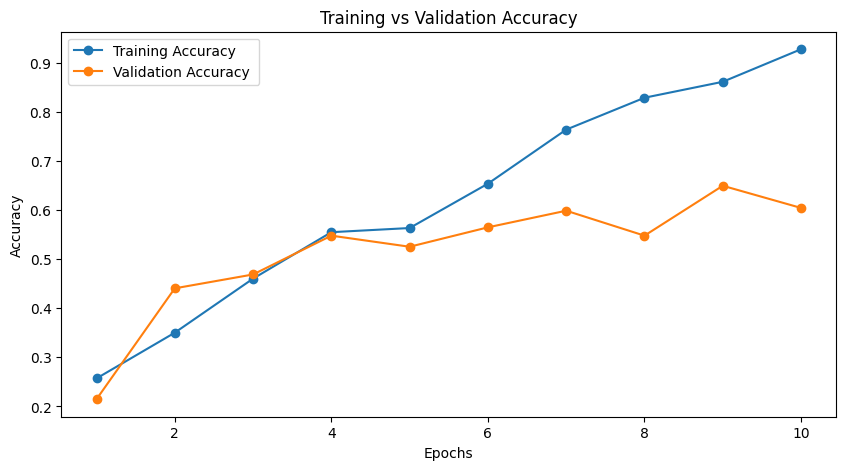

In [20]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
epochs=range(1,EPOCH+1)

plt.figure(figsize=(10,5))
plt.plot(epochs,train_accuracy,label='Training Accuracy',marker='o')
plt.plot(epochs,val_accuracy,label='Validation Accuracy ',marker='o')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
EPOCHS=20

history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
    
    
    )

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 500ms/step - accuracy: 0.9336 - loss: 0.2094 - val_accuracy: 0.6215 - val_loss: 1.5936
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - accuracy: 0.9760 - loss: 0.0803 - val_accuracy: 0.6610 - val_loss: 1.6663
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 469ms/step - accuracy: 0.9845 - loss: 0.0578 - val_accuracy: 0.6441 - val_loss: 2.0903
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 472ms/step - accuracy: 0.9944 - loss: 0.0465 - val_accuracy: 0.6328 - val_loss: 1.8896
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 494ms/step - accuracy: 0.9958 - loss: 0.0325 - val_accuracy: 0.6441 - val_loss: 1.9184
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.9972 - loss: 0.0234 - val_accuracy: 0.6836 - val_loss: 2.0952
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 467ms/step - accuracy: 0.9944 - loss: 0.0551 - val_accuracy: 0.6215 - val_loss: 1.8249
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 481ms/step - accuracy: 0.9944 - loss: 0.0267 - val_accu

## Solve the Overfitting problem

In [23]:
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255,input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))

model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))
model.add(tf.keras.layers.Dropout(0.3))


model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(128,activation='relu'))

model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
EPOCHS=10

In [26]:
model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
    )

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 917ms/step - accuracy: 0.3927 - loss: 20.0570 - val_accuracy: 0.1299 - val_loss: 12.4273
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 988ms/step - accuracy: 0.5678 - loss: 2.5925 - val_accuracy: 0.2429 - val_loss: 68.6168
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 955ms/step - accuracy: 0.6653 - loss: 1.0604 - val_accuracy: 0.2542 - val_loss: 73.7892
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 927ms/step - accuracy: 0.7373 - loss: 0.7630 - val_accuracy: 0.2768 - val_loss: 51.5771
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 949ms/step - accuracy: 0.8079 - loss: 0.6151 - val_accuracy: 0.2147 - val_loss: 27.1331
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 953ms/step - accuracy: 0.8277 - loss: 0.5687 - val_accuracy: 0.1469 - val_loss: 24.4932
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 931ms/step - accuracy: 0.8390 - loss: 0.5981 - val_accuracy: 0.2203 - val_loss: 12.0834
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 940ms/step - accuracy: 0.8602 - loss: 0.4701 - 

## Grok.com's recommendation

In [27]:
data_argumentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15)
])

In [29]:
model=tf.keras.models.Sequential()

model.add(data_argumentation)
model.add(tf.keras.layers.Rescaling(1./255,input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))

model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.25))


model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.25))



model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.35))


model.add(tf.keras.layers.Flatten())


model.add(tf.keras.layers.Dense(256,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.5))


model.add(tf.keras.layers.Dense(128,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.5))


model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)


reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

call_backs=[early_stopping,reduce_lr]

history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=call_backs,
    verbose=1
)

print("\n Training Complete")
print(f"Best Validation accuracy :{max(history.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.3037 - loss: 2.9248 - val_accuracy: 0.2429 - val_loss: 3.7958 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.4167 - loss: 2.5839 - val_accuracy: 0.2429 - val_loss: 5.5037 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4124 - loss: 2.6607 - val_accuracy: 0.2429 - val_loss: 4.8246 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5055 - loss: 2.3793
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4675 - loss: 2.4681 - val_accuracy: 0.2429 - val_loss: 5.5806 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.4590 - loss: 2.4254 - val_accuracy: 0.2429 - val_loss: 6.4763 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5042 - loss: 2.324

## Insights so far

## Transfer Learning - MobileNetV2

In [30]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [31]:
base_model.trainable=False

model=tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_argumentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 506ms/step - accuracy: 0.4802 - loss: 1.5135 - val_accuracy: 0.5876 - val_loss: 1.1383
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 404ms/step - accuracy: 0.6709 - loss: 0.9045 - val_accuracy: 0.6497 - val_loss: 0.9297
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 439ms/step - accuracy: 0.7472 - loss: 0.7275 - val_accuracy: 0.6554 - val_loss: 0.9454
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 443ms/step - accuracy: 0.7514 - loss: 0.6609 - val_accuracy: 0.6497 - val_loss: 0.9596
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.7895 - loss: 0.5747 - val_accuracy: 0.7119 - val_loss: 0.7839
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step - accuracy: 0.8023 - loss: 0.5816 - val_accuracy: 0.6497 - val_loss: 0.9661
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.8404 - loss: 0.4513 - val_accuracy: 0.6723 - val_loss: 0.8813
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step - accuracy: 0.7867 - loss: 0.5593 - val_accu

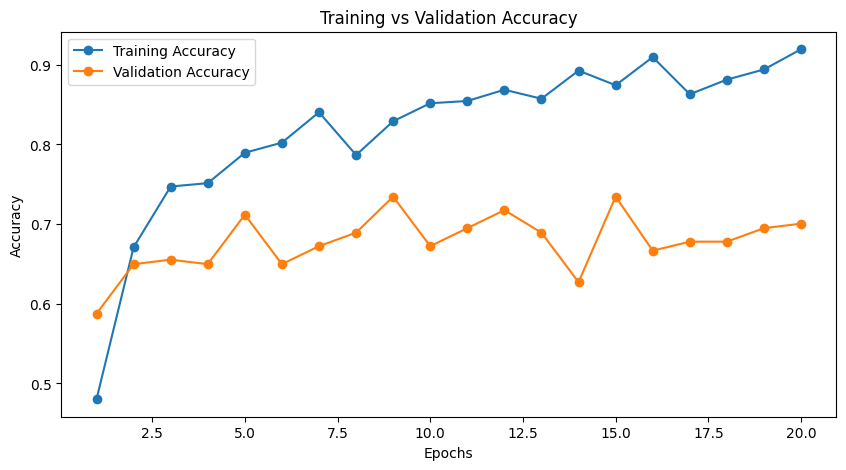

In [35]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
epochs=range(1,21)

plt.figure(figsize=(10,5))
plt.plot(epochs,train_accuracy,label='Training Accuracy ',marker='o')
plt.plot(epochs,val_accuracy,label='Validation Accuracy',marker='o')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [36]:
model.save("../Models/MobileNetV2.h5")

## EfficientNet

In [38]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    image_size=(IMG_WIDTH,IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [40]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [41]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [42]:
num_classes=len(class_names)

In [43]:
num_classes

6

In [44]:
class_counts={}
total_images=0

for class_name in class_names:
    class_path=os.path.join(DATASET_DIR,class_name)
    count=len(os.listdir(class_path))
    class_counts[class_name]=count
    total_images+=count

In [49]:
class_weights={}

for index,class_name in enumerate(class_names):
    class_weights[index]=total_images/(num_classes*class_counts[class_name])

print("class Weights",class_weights)

class Weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [50]:
data_argumentation=tf.keras.Sequential()
data_argumentation.add(tf.keras.layers.RandomFlip('horizontal'))
data_argumentation.add(tf.keras.layers.RandomRotation(0.1))
data_argumentation.add(tf.keras.layers.RandomZoom(0.1))

In [51]:
train_images=[]
train_labels=[]

In [52]:
for images ,labels in train_dataset:
    images=tf.keras.applications.efficientnet.preprocess_input(images)
    train_images.append(images)
    train_labels.append(labels)

In [53]:
train_images=tf.concat(train_images,axis=0)
train_labels=tf.concat(train_labels,axis=0)

In [56]:
validation_images=[]
validation_labels=[]

In [57]:
for images ,labels in validation_dataset:
    images=tf.keras.applications.efficientnet.preprocess_input(images)
    validation_images.append(images)
    validation_labels.append(labels)

In [59]:
validation_images=tf.concat(validation_images,axis=0)
validation_labels=tf.concat(validation_labels,axis=0)

In [66]:
base_model=tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [67]:
base_model.trainable=False

In [68]:
model=tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_argumentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [69]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [71]:
model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 760ms/step - accuracy: 0.5000 - loss: 1.3037 - val_accuracy: 0.6045 - val_loss: 0.9725
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 526ms/step - accuracy: 0.7444 - loss: 0.7406 - val_accuracy: 0.7175 - val_loss: 0.7789
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 499ms/step - accuracy: 0.8037 - loss: 0.5808 - val_accuracy: 0.7458 - val_loss: 0.7599
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 504ms/step - accuracy: 0.8291 - loss: 0.4990 - val_accuracy: 0.7571 - val_loss: 0.7019
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step - accuracy: 0.8588 - loss: 0.4562 - val_accuracy: 0.7401 - val_loss: 0.7037
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 497ms/step - accuracy: 0.8715 - loss: 0.4018 - val_accuracy: 0.7627 - val_loss: 0.6420
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 548ms/step - accuracy: 0.8912 - loss: 0.3217 - val_accuracy: 0.7740 - val_loss: 0.6264
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 545ms/step - accuracy: 0.9124 - loss: 0.2979 - val_accu

## Hyper Parameter Optimization

In [74]:
import keras_tuner as kt

In [79]:
def build_model(hp):
    base_model=tf.keras.applications.EfficientNetB0(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
        )
    base_model.trainable=False

    model=tf.keras.models.Sequential(
        [
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(hp.Float("rotation_factor",min_value=0.05,max_value=0.3,step=0.05)),
            tf.keras.layers.RandomZoom(hp.Float("zoom_factor",min_value=0.05,max_value=0.3,step=0.05)),
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.1)),
            tf.keras.layers.Dense(hp.Int('dense_units',min_value=64,max_value=512,step=64),activation='relu'),
            tf.keras.layers.Dense(num_classes,activation='softmax')
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float("learning_rate",min_value=1e-4,max_value=1e-2,sampling='log')),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']

    )
    return model

tuner=kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='kt-dir',
    project_name='efficientnet_tune',
    overwrite=True
)


early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True)


tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights
)

best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:")
print(best_hps.values)

best_model=tuner.get_best_models(num_models=1)[0]

val_loss,val_acc=best_model.evaluate(validation_dataset)
print(f"Best Validation Accuracy :{val_acc:.4f}")

Trial 20 Complete [00h 02m 21s]
val_accuracy: 0.7570621371269226

Best val_accuracy So Far: 0.8305084705352783
Total elapsed time: 01h 14m 34s
Best Hyperparameters:
{'rotation_factor': 0.1, 'zoom_factor': 0.1, 'dropout_rate': 0.1, 'dense_units': 128, 'learning_rate': 0.0018290793529110935}
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 340ms/step - accuracy: 0.8305 - loss: 0.5819
Best Validation Accuracy :0.8305


In [80]:
best_model.save("../Models/effnet_finetune.h5")